In [2]:
!apt-get install -y libzbar0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-double3
  libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0 libjxr-tools libjxr0
  liblqr-1-0 libmagickcore-6.q16-6 libmagickcore-6.q16-6-extra
  libmagickwand-6.q16-6 libv4l-0 libv4lconvert0 libwmflite-0.2-7 poppler-data
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf fonts-texgyre
  ghostscript-x libfftw3-bin libfftw3-dev inkscape poppler-utils
  fonts-japanese-mincho | fonts-ipafont-mincho fonts-japanese-gothic
  | fonts-ipafont-gothic fonts-arphic-ukai fonts-arphic-uming fonts-nanum
The following NEW packages will be installed:
  fonts-droid-fallback fonts-noto-mono fonts-urw-base35 ghostscript gsfonts
  imagemagick-6-common libdjvulibre-text libdjvulibre21 libfftw3-

In [3]:
!pip install qrcode opencv-python pyzbar pillow


==== QR Code Generator & Decoder ====
Select an option: [g] Generate QR | [d] Decode QR
Enter choice (g/d): g
Enter text or URL to generate QR code: https://colab.research.google.com/drive/1ydKHRg-m9QYEa_s9w2gCUJaycBeHfH0L#scrollTo=7_07H3hr3ljn
Enter filename (e.g., mycode.png): mohsin.png
[✅] QR Code generated and saved as 'mohsin.png'.


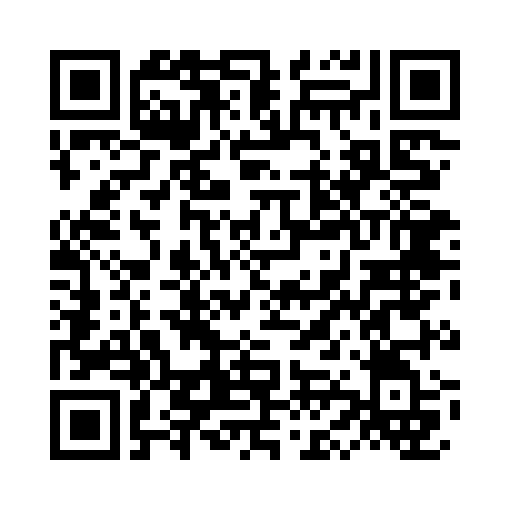

In [4]:
# 📦 Install required packages
!pip install qrcode opencv-python pyzbar pillow

# 📁 Import necessary modules
import qrcode
import cv2
from pyzbar.pyzbar import decode
from PIL import Image
from google.colab import files

# 🧠 QR Code Generator Function
def generate_qr(data: str, filename: str = "qrcode.png"):
    qr = qrcode.QRCode(version=1, box_size=10, border=5)
    qr.add_data(data)
    qr.make(fit=True)

    img = qr.make_image(fill="black", back_color="white")
    img.save(filename)
    print(f"[✅] QR Code generated and saved as '{filename}'.")

    # Display in Colab
    display(Image.open(filename))

# 🔍 QR Code Decoder Function
def decode_qr(image_path: str):
    img = cv2.imread(image_path)
    decoded_objects = decode(img)

    if not decoded_objects:
        print("[❌] No QR code found.")
        return

    for obj in decoded_objects:
        print(f"[🔍] Decoded Data: {obj.data.decode('utf-8')}")

# --- 👇 User Interface ---
print("==== QR Code Generator & Decoder ====")
print("Select an option: [g] Generate QR | [d] Decode QR")

choice = input("Enter choice (g/d): ").strip().lower()

if choice == 'g':
    text = input("Enter text or URL to generate QR code: ")
    filename = input("Enter filename (e.g., mycode.png): ").strip() or "qrcode.png"
    generate_qr(text, filename)

elif choice == 'd':
    print("Please upload the QR code image...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        decode_qr(filename)

else:
    print("[⚠️] Invalid choice. Use 'g' or 'd'.")
